# 5. Classification Analysis - Phân loại dữ liệu
## Mục đích
Đây là mô hình học có giám sát, mục đích là dạy cho máy tính cách gán một label cho một dữ liệu mới, dựa trên những kinh nghiệm nó đã học từ dữ liệu trong quá khứ. 

Mô hình sử dụng là ***Random Forest***. Đầu vào được cung cấp là các bài hát cùng các đặc trưng âm học. Đầu ra là câu trả lời của mô hình rằng bài hát này thuộc lớp 'Hit' hay 'Not Hit'.

***Cách bước tiến hành***
1. Phân tách dữ liệu
2. Chia tập Train và Test
3. Khởi tạo và huấn luyện mô hình
4. Đánh giá mô hình
5. Trực quan hóa dữ liệu

## [*] Tải thư viện và tập dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Tải tập dữ liệu cần thiết lập spotify_for_ml.csv
df_fe = pd.read_csv('../data/processed/spotify_for_ml.csv')
print(f"Đã tải dữ liệu: {df_fe.shape[0]} dòng, {df_fe.shape[1]} cột")

Đã tải dữ liệu: 12476 dòng, 327 cột


## 1. Phân tách dữ liệu
- Biến mục tiêu (y): là cột `is_hit` trong dataset đã được tạo trong `feature_engineering`
- Biến độc lập (X): là toàn bộ các đặc trưng âm học `audio_features`

In [2]:
# Loại bỏ các cột không cần thiết khỏi X để tránh rò rỉ đáp án
df_fe = df_fe.dropna().reset_index(drop=True)
# Chuyển cột 'explicit' thành số nếu nó tồn tại
if 'explicit' in df_fe.columns:
    df_fe['explicit'] = df_fe['explicit'].astype(int)
drop_cols = ['is_hit', 'track_id', 'track_name', 'track_number', 'artist_name', 'artist_popularity', 'artist_followers','album_id', 'album_name', 'album_release_date', 'album_type', 'album_total_tracks', 'track_popularity']
X = df_fe.drop(columns = [col for col in drop_cols if col in df_fe.columns])
X = X.loc[:, ~X.columns.str.startswith('genre_')]
y = df_fe['is_hit']
print("Đã chuẩn bị dữ liệu cho mô hình phân loại.")
print(f"Kích thước tập X: {X.shape[0]} dòng và {X.shape[1]} cột")
print(f"Kích thước tập y: {y.shape[0]} dòng") 


Đã chuẩn bị dữ liệu cho mô hình phân loại.
Kích thước tập X: 12476 dòng và 12 cột
Kích thước tập y: 12476 dòng


## 2. Chia tập dữ liệu
Tách dữ liệu theo tỷ lệ 80% để huấn luyện (train) và 20% để test (kiểm tra). 

In [3]:
# Chia dữ liệu thành tập huấn luyện và tập kiểm tra, stratify = y để đảm bảo tỷ lệ Hit/Not Hit ở 2 tập như nhau
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"1. Kích thước tập train: {X_train.shape[0]} bài hát")
print(f"Phân bố nhãn: {y_train.value_counts(normalize=True)[0]*100:.1f}% Not Hit | {y_train.value_counts(normalize=True)[1]*100:.1f}% Hit")
print(f"2. Kích thước tập test: {X_test.shape[0]} bài hát")
print(f"Phân bố nhãn: {y_test.value_counts(normalize=True)[0]*100:.1f}% Not Hit | {y_test.value_counts(normalize=True)[1]*100:.1f}% Hit")

1. Kích thước tập train: 9980 bài hát
Phân bố nhãn: 66.5% Not Hit | 33.5% Hit
2. Kích thước tập test: 2496 bài hát
Phân bố nhãn: 66.5% Not Hit | 33.5% Hit


## 3. Khởi tạo và huấn luyện mô hình
- Sử dụng tham số `class_weight = 'balanced'` để mô hình tự động phạt nặng hơn nếu nó đoán sai lớp bài Hit.
- Dùng kỹ thuật `RandomizedSearchCV` để máy tính tự động dò tìm xem trồng bao nhiêu cây, độ sâu của cây là bao nhiêu để thu được kết quả tốt nhất.
- Lấy random mẫu từ `X_train` để từng cây học (Bagging).


In [4]:
# Huấn luyện mô hình Random Forest với class_weight='balanced'
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
# Chạy huấn luyện mô hình
rf.fit(X_train, y_train)
print("Mô hình đã được huấn luyện xong.")

Mô hình đã được huấn luyện xong.


## 4. Đánh giá mô hình 
Dùng tập `X_test` để mô hình dự đoán, sau đó so sánh kết quả với tập `y_test`.
- Ma trận nhầm lẫn: Xem tỷ lệ đoán trúng bài Hit thật.
- Báo cáo phân loại: 

1. Báo cáo phân loại:
              precision    recall  f1-score   support

     Not Hit       0.88      0.87      0.87      1661
         Hit       0.74      0.75      0.75       835

    accuracy                           0.83      2496
   macro avg       0.81      0.81      0.81      2496
weighted avg       0.83      0.83      0.83      2496

2. Ma trận nhầm lẫn:


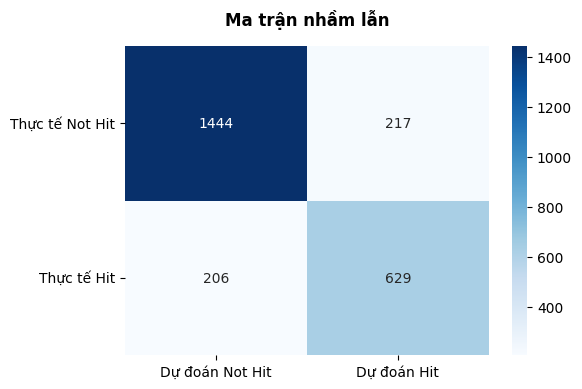

In [5]:
# Dự đoán trên tập test
y_pred = rf.predict(X_test)
# Tạo báo cáo phân loại
print("1. Báo cáo phân loại:")
print(classification_report(y_test, y_pred, target_names=['Not Hit', 'Hit']))

# Tạo ma trận nhầm lẫn
print("2. Ma trận nhầm lẫn:")
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Dự đoán Not Hit', 'Dự đoán Hit'], yticklabels=['Thực tế Not Hit', 'Thực tế Hit'])
plt.title('Ma trận nhầm lẫn', pad = 15, fontweight = 'bold')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Trực quan hóa đặc trưng quan trọng
Vẽ biểu đồ top 15 đặc trưng quan trọng nhất để quyết định bài Hit

Điểm `importances` được tính bằng thuật toán MDI (Mean Decrease in Impurity)

C:\Users\Admin\AppData\Local\Temp\ipykernel_19660\3408391574.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='importance', y='feature', data=df_importance.sort_values(by='importance', ascending=False).head(15), palette='pastel')


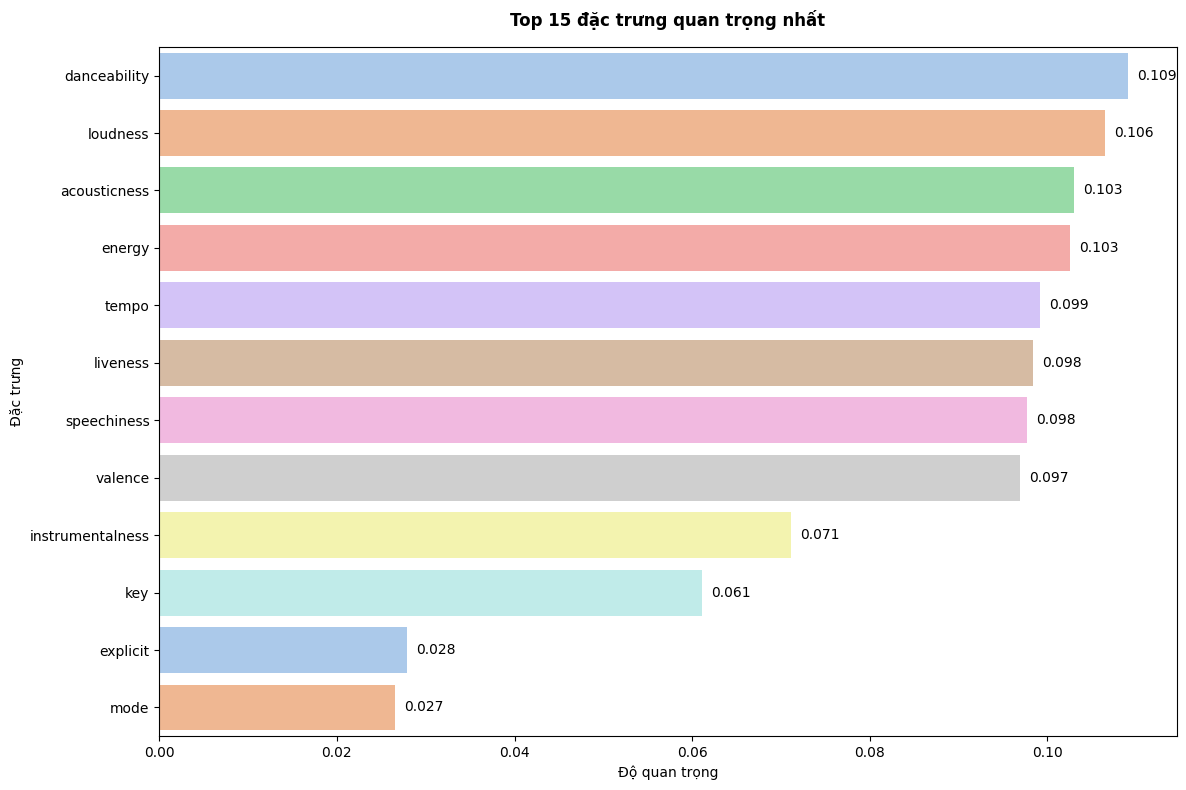

In [6]:
importances = rf.feature_importances_
feature_names = X.columns
df_importance = pd.DataFrame({'feature': feature_names, 'importance': importances})

plt.figure(figsize=(12, 8))
ax = sns.barplot(x='importance', y='feature', data=df_importance.sort_values(by='importance', ascending=False).head(15), palette='pastel')
plt.title('Top 15 đặc trưng quan trọng nhất', pad = 15, fontweight = 'bold')
plt.xlabel('Độ quan trọng')
plt.ylabel('Đặc trưng')
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.001, p.get_y() + p.get_height() / 2, f'{width:.3f}', va='center')
plt.tight_layout()
plt.show()

In [7]:
# Lưu lại kết quả thực thi
# Tạo cột predicted_hit lưu kết quả dự đoán của mô hình và cột is_correct để so sánh với kết quả thực tế
# Lưu tại file ../data/processed/spotify_with_classification.csv
df_final = df_fe.copy()
df_final['predicted_hit'] = rf.predict(X)
df_final['is_correct'] = (df_final['is_hit'] == df_final['predicted_hit']).astype(int)
output_path = '../data/processed/spotify_with_classification.csv'
df_final.to_csv(output_path, index=False)
print(f"Đã lưu kết quả phân loại vào: {output_path}")

Đã lưu kết quả phân loại vào: ../data/processed/spotify_with_classification.csv
